# Isogrid Module Calculator
Supports both regular isogrid and open web calculations.
Does not optimize

### Definitions from Handbook for translating equations
t = thickness of Skin  
b = width of rib web  
d = depth of web  
c = depth of flange  
w = width of flange  
s = t+d = plate thickness of unflanged isogrid  
h = height of triangle  
a = leg of triangle (center to center of nodes)  
kc = column fixity

beta = b/a  (width of rib web/leg of triangle)  


[6.0625, 0.0, 0.07, 0.06, 24, 'Open Web 24 (Current)']
PASS - Rib shape acceptable (depth > width)
Tbar 0.016
Beta 0.064
E_star 6.400e+05
h 0.812
a 0.938
Inradius: 0.271, hole diameter: 0.541
General Instability - 283.7 lbf/in   5528 lbf
Rib Cripling        - 521.9 lbf/in  10169 lbf
Rel Weight:  1.2
Rel Strength: 0.71

[6.0625, 0.0, 0.095, 0.06, 18, 'Open Web 18']
PASS - Rib shape acceptable (depth > width)
Tbar 0.016
Beta 0.048
E_star 4.762e+05
h 1.091
a 1.260
Inradius: 0.364, hole diameter: 0.728
General Instability - 385.6 lbf/in   7575 lbf
Rib Cripling        - 291.7 lbf/in   5729 lbf
Rel Weight: 1.21
Rel Strength: 0.736

[6.0625, 0.0, 0.25, 0.07, 12, 'Open Web 12']
PASS - Rib shape acceptable (depth > width)
Tbar 0.031
Beta 0.035
E_star 3.529e+05
h 1.718
a 1.984
Inradius: 0.573, hole diameter: 1.145
General Instability - 1885.6 lbf/in  38874 lbf
Rib Cripling        - 312.4 lbf/in   6440 lbf
Rel Weight: 1.88
Rel Strength: 0.827

[6.0625, 0.0, 0.25, 0.09, 9, 'Open Web 9']
PASS - Ri

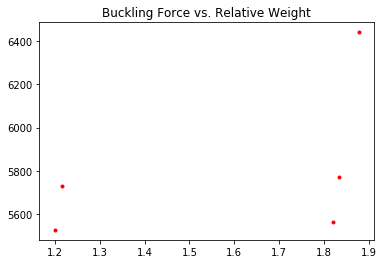

In [30]:
import math
import matplotlib.pyplot as plt

# Material properties 
E = 69.0 # Young's Modules, GPa for Al 6061-T6
E_imp = 10000*1000 # PSI
nu = 0.33 # Poisson's Ratio for Al 6061-T6
material_name = '6061-T6'
F_ty = 40 # ksi (Yield Strength)
F_tu = 45 # ksi (Ultimate Strength)

# Instability Coefs
c0 = 0.397    # 4.2.005
c1 = 10.2     # 4.2.006
c2 = 0.616    # 4.2.008

kc = 2.0 # assumed on page 4.9.009

# Common Properties
flanges = False

# Parametric Space
# Inner Diameter, wall_t, rib_depth, rib_width, num_cells, Name
module_options = [
                  [6.0625,0.00,0.07,0.06,24, 'Open Web 24 (Current)'],
                  [6.0625,0.00,0.095,0.06,18, 'Open Web 18'],
                  [6.0625,0.00,0.25,0.07,12, 'Open Web 12'],
                  [6.0625,0.00,0.25,0.09,9, 'Open Web 9'],
                  [6.0625,0.00,0.25,0.10,8, 'Open Web 8'],
                 ]
results = []
for module in module_options:
    print()
    print(module)
    module_id = module[0]
    skin_t = module[1]
    rib_depth = module[2]
    rib_width = module[3]
    num_radial_divisions = module[4]
    module_od = module_id+2*rib_depth
    module_r = module_od/2
    rel_weight_data = []
    pattern_size = module_od*math.pi/num_radial_divisions
    cell_height = pattern_size
    a = 2*cell_height/(3**0.5)
    A = cell_height*a/2
    s = (3*a/2)
    inradius = A/s


    if skin_t == 0.0:
        # Open Web
        # Check that rib depth > rib_width (d>b)
        if rib_depth > rib_width:
            print('PASS - Rib shape acceptable (depth > width)')
        else:
            print('FAIL - Rib depth needs to be greater than rib width')
        E_bar = E_imp*rib_width/a
        t_bar = 3*rib_width*rib_depth/cell_height
        beta = rib_width/a
        N_cr_1 = 0.612*c0*E_imp*(rib_width*rib_depth*rib_depth)/(module_r*cell_height) # Eqn 4.9.8 (Rectangular Stiffeners)
        N_cr_2 = 1.422*kc*E_imp*rib_depth*(beta**3) # Eqn 4.9.10
        
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2)
    
        print(f'Tbar {t_bar:.3f}')
        print(f'Beta {beta:.3f}')
        print(f'E_star {E_bar:.3e}')
        print(f'h {cell_height:.3f}')
        print(f'a {a:.3f}')
        print(f'Inradius: {inradius:.3f}, hole diameter: {2*inradius:.3f}')
        print('General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
    else:
        # Closed Web
        alpha = (rib_width*rib_depth)/(skin_t*cell_height) # Web non-dimensional ratio, pg. 2.0.008
        delta = rib_depth/skin_t # rib depth to skin thickness ratio, pg. 2.0.008
        if flanges == False:
            beta = (3*alpha*(1+delta)**2+(1+alpha)*(1+alpha*delta**2))**0.5
            t_star = skin_t*beta/(1+alpha) # equivilent thickness, Eq. 2.5.3
            t_bar = skin_t*(1+3*alpha)
            E_star = E*(1+alpha)**2.0/beta # equivilent Young's Modulus Eq. 2.5.4#
        N_cr_1 = c0*E_imp*skin_t*skin_t/module_r*beta
        N_cr_2 = c1*E_imp*skin_t*(1+alpha)*(skin_t*skin_t)/(pattern_size*pattern_size)
        N_cr_3 = c2*E_imp*skin_t*(1+alpha)*(rib_width*rib_width)/(rib_depth*rib_depth)
    
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        F_cr_3 = N_cr_3*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2,F_cr_3)
    
        print(f'Tbar {t_bar:.3f}')
        print('General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('Skin Buckling       - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
        print('Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_3,F_cr_3))
            
    cs_area = t_bar*2*math.pi*(module_r+t_bar/2)
    if skin_t == 0.0:
        # Note: We add the weight of skin to the weight
        cs_area = (t_bar+0.016)*2*math.pi*(module_r+t_bar/2)
    rel_w = cs_area/0.513412
    print('Rel Weight: {:4.3}'.format(rel_w))
    print('Rel Strength: {:4.3}'.format(strength/7783))
    rel_weight_data.append(rel_w)
    results.append([module_id, rel_w, strength])

# Buckling
buckling_plot = plt.figure(1)
plt.title('Buckling Force vs. Relative Weight')
for item in results:
    plt.plot(item[1], item[2], 'r.', label='id_'+str(item[0]))
#plt.legend()



## Load Calculations

In [18]:
pi = 3.14159

# Inputs
# Numbers from LV4, these need to be updated to be finalized
F = 1.573 # Klbf ~7000 N
M = 1.200 # K in = 30 Nm
R = 6.0625 # in

b = 0.06 # in
d = 0.07 # in
h = 0.812
Ao = b*d

Nx_max = F/(2*math.pi*R) + M/(pi*R**2)
print(f'Nx_max: {Nx_max:3.2f} k/in')

sigma_1 = h/(3*Ao)*Nx_max
sigma_2 = 2*h/(3*Ao)*Nx_max
print(f'Sigma_1 {sigma_1:3.2f} ksi')
print(f'Sigma_2 {sigma_2:3.2f} ksi')



Nx_max: 0.05 k/in
Sigma_1 3.33 ksi
Sigma_2 6.66 ksi
